02_modelingでは、sensor_04を対象として、
<br>前処理→周期性の確認(ACF,PACF)→ARIMAモデリング→異常検知の設計→評価
<br>を行った。

本notebookでは、
- sensor_04
- sensor_39
- sensor_41
- sensor_42
<br>の四つのセンサーについて、解析を行うこととする。

大きな流れとしては
- 4つのセンサーに対して、ARIMAを適用
- 別方法として、Isolation Forestを適用
- ARIMAとIsolation Forestのアンサンブル

## 4つのセンサーに対して、ARIMAを適用

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_dir = Path('../data/raw/')
df = pd.read_csv(data_dir/'sensor.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

In [2]:
sensors = ['sensor_04', 'sensor_39', 'sensor_41', 'sensor_42']

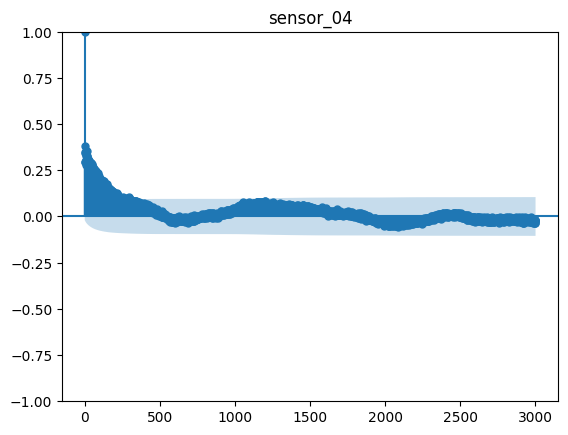

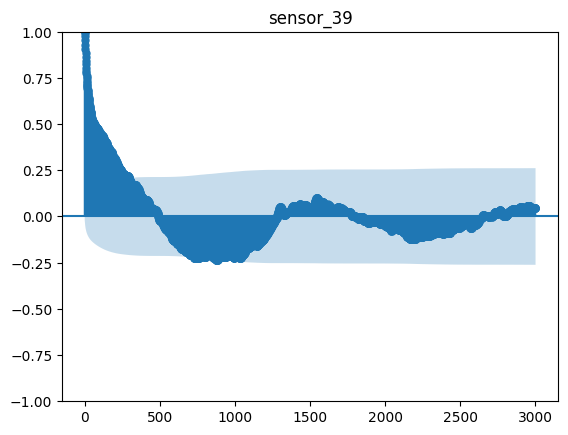

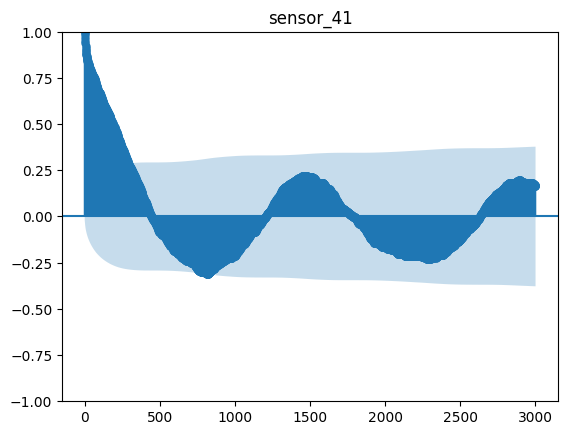

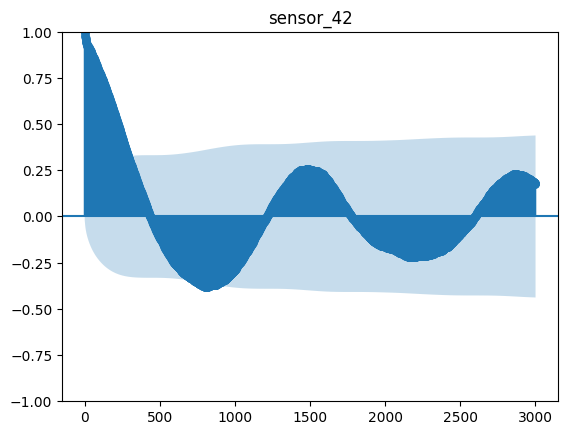

In [3]:
for col in sensors:
    d = df[col].interpolate(method = 'linear')
    plot_acf(d[:10080], lags=3000)
    plt.title(col)
    plt.show()

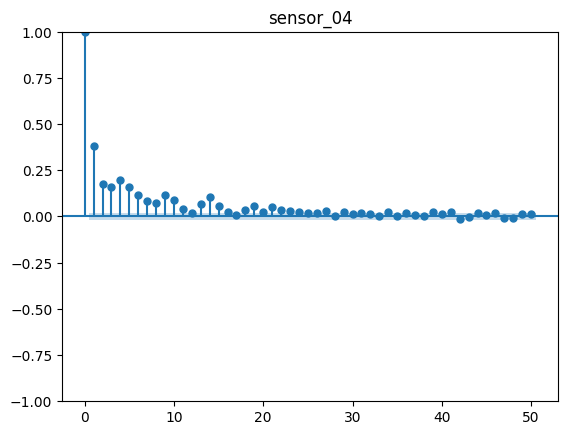

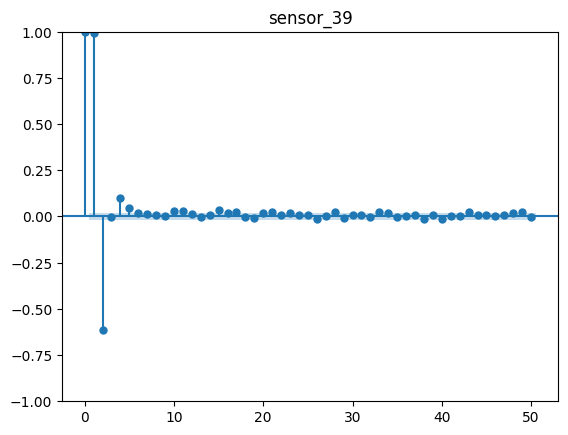

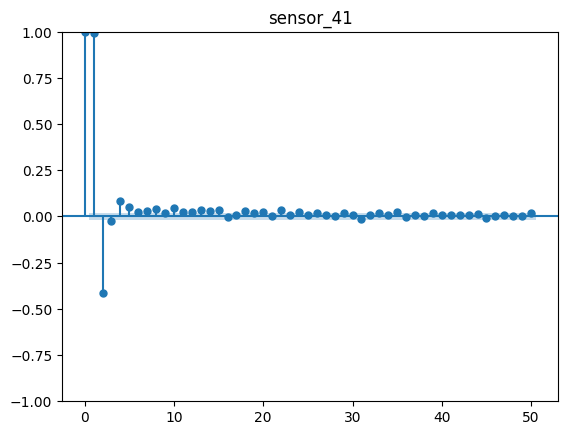

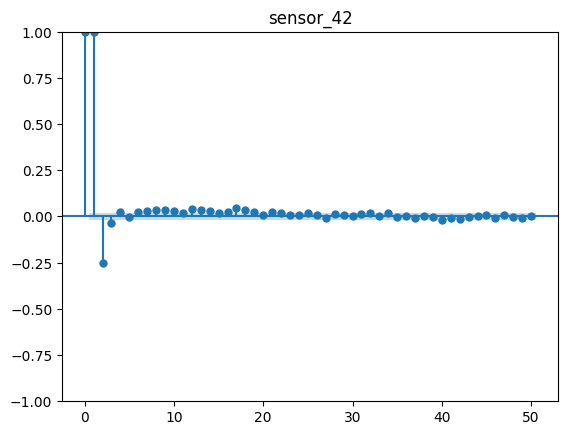

In [4]:
for col in sensors:
    d = df[col].interpolate(method = 'linear')
    plot_pacf(d[:10080], lags=50)
    plt.title(col)
    plt.show()

どのセンサーもPACFでt=1以降に急激に値が落ちていることから、AR(1)であることが濃厚。

In [5]:
from statsmodels.tsa.stattools import adfuller
for col in sensors:
    d = df[col].interpolate(method = 'linear')
    stat, pval, *_ = adfuller(d)
    print(f'{col}: p値={pval:.4f}')

sensor_04: p値=0.0000
sensor_39: p値=0.0000
sensor_41: p値=0.0000
sensor_42: p値=0.0000


ADFの結果、全てp < 0.05より、
<br>どのセンサーもARIMA(1,0,0)を適用する。

In [6]:
status_map = {'NORMAL':0, 'RECOVERING':1, 'BROKEN':2}
df['status_num'] = df['machine_status'].map(status_map)

In [7]:
from statsmodels.tsa.arima.model import ARIMA

In [8]:
def vis(sensor, a_ratio, b_ratio):
    d = df[sensor].interpolate(method = 'linear')
    d_normal = d[df['machine_status']=='NORMAL']

    model = ARIMA(d_normal, order = (1,0,0))
    applied_to_full = model.fit().apply(d)
    residuals = applied_to_full.resid

    resid_normal_std = residuals[df['machine_status']=='NORMAL'].std()

    a_thres = a_ratio * resid_normal_std
    b_thres = b_ratio * resid_normal_std

    rolling_std = residuals.rolling(window=50).std()

    int_signal_a = (residuals.abs() > a_thres).astype(int)
    int_signal_b = (rolling_std < b_thres).astype(int)

    plt.figure()
    fig, ax1 = plt.subplots(figsize = (20,10))
    ax1.plot(df.index, int_signal_a)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['status_num'], alpha = 0.5, color = 'red')
    plt.show()

    plt.figure()
    fig, ax1 = plt.subplots(figsize = (20,10))
    ax1.plot(df.index, int_signal_b)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['status_num'], alpha = 0.5, color = 'red')
    plt.show()


/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used

<Figure size 640x480 with 0 Axes>

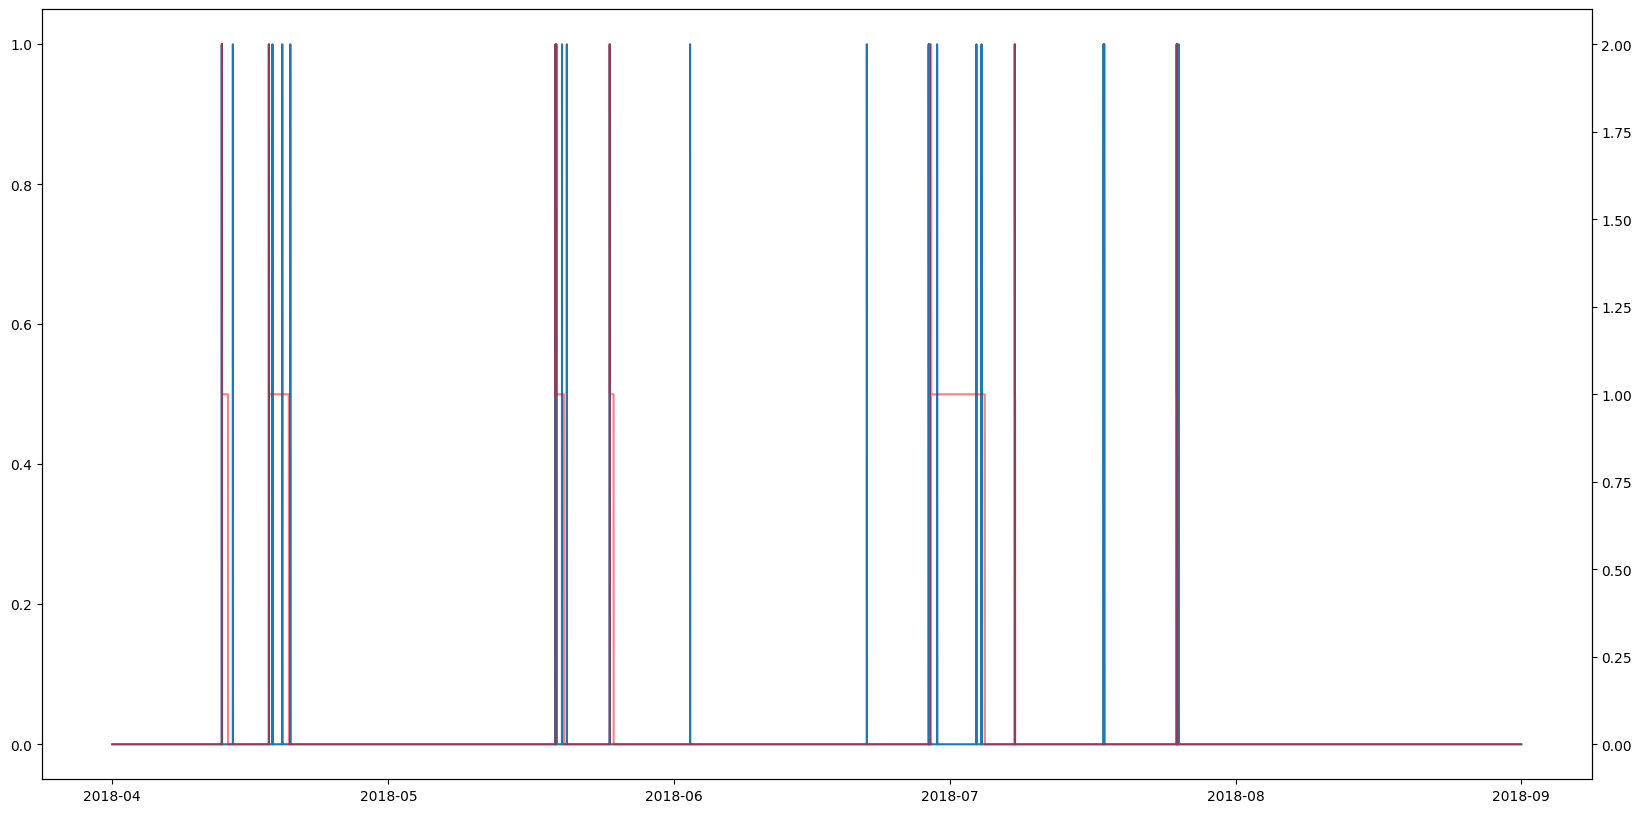

<Figure size 640x480 with 0 Axes>

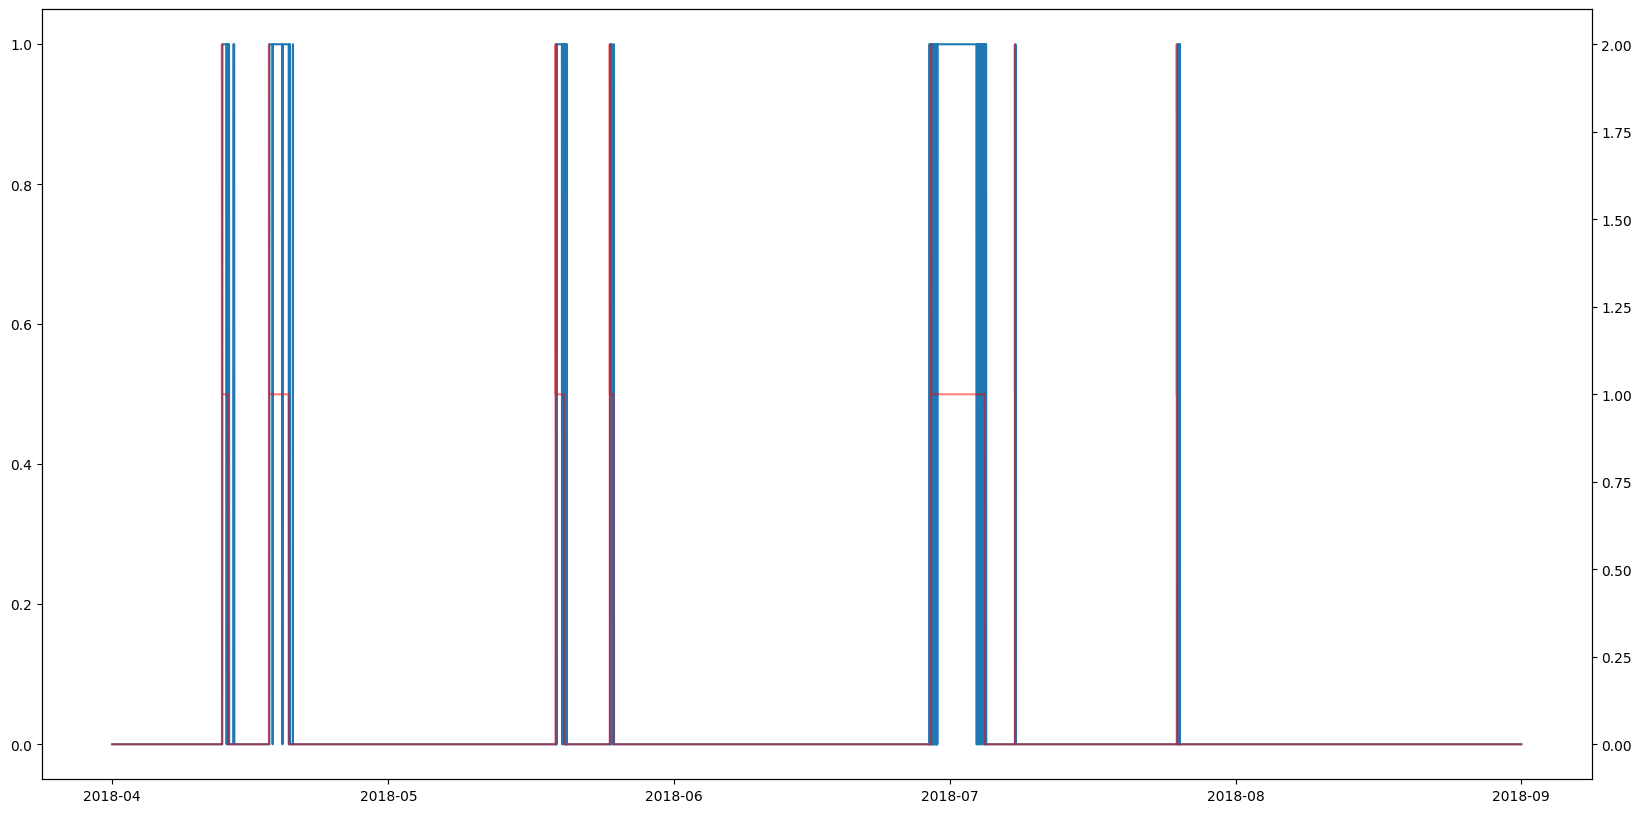

In [9]:
vis('sensor_04', 20, 0.35)

/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used

<Figure size 640x480 with 0 Axes>

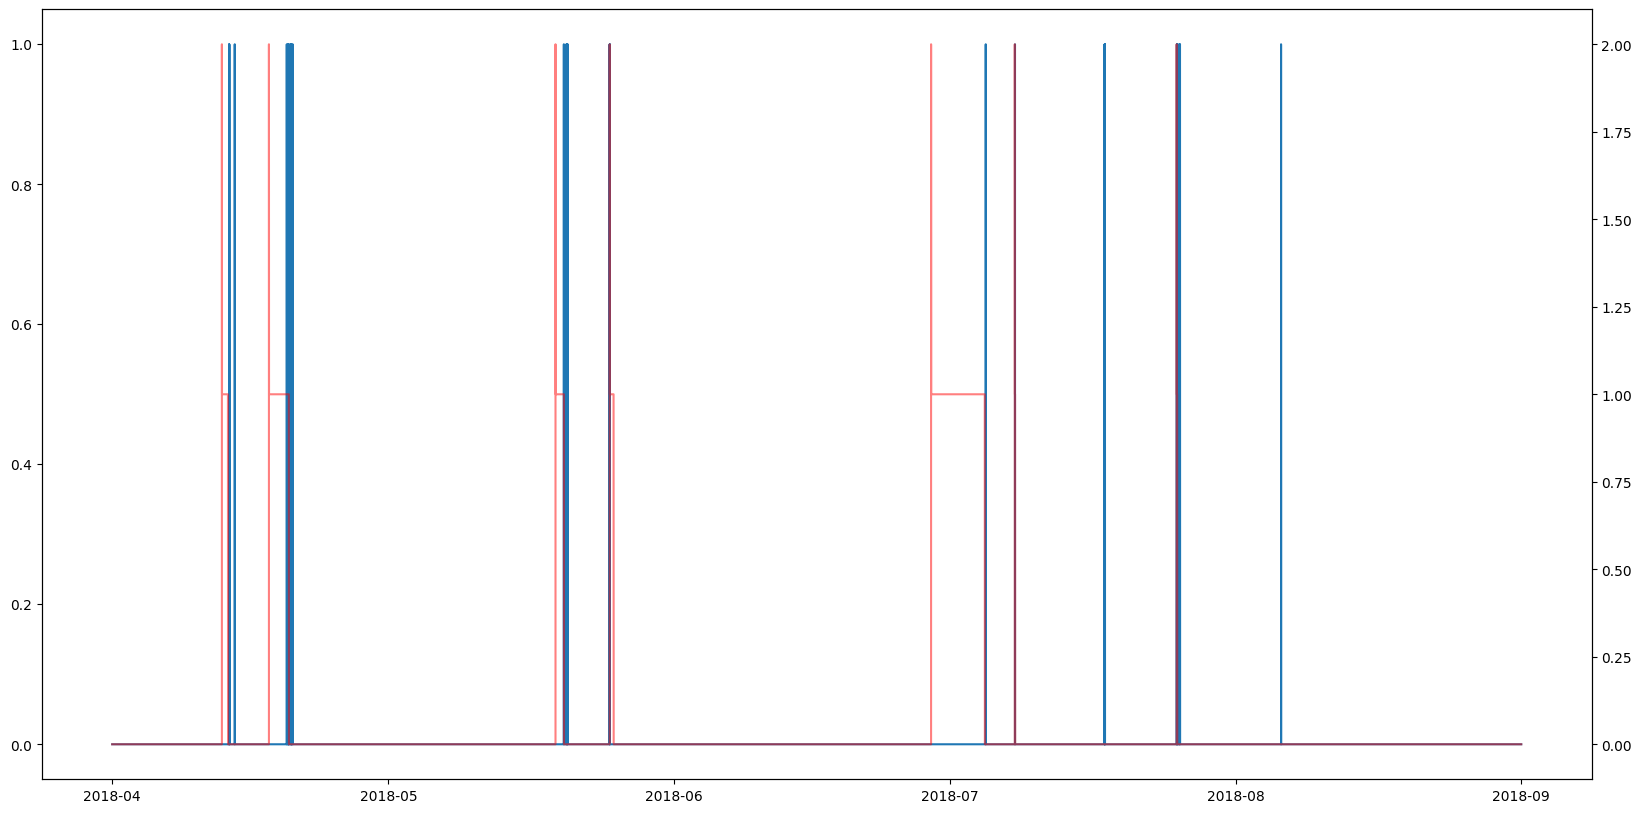

<Figure size 640x480 with 0 Axes>

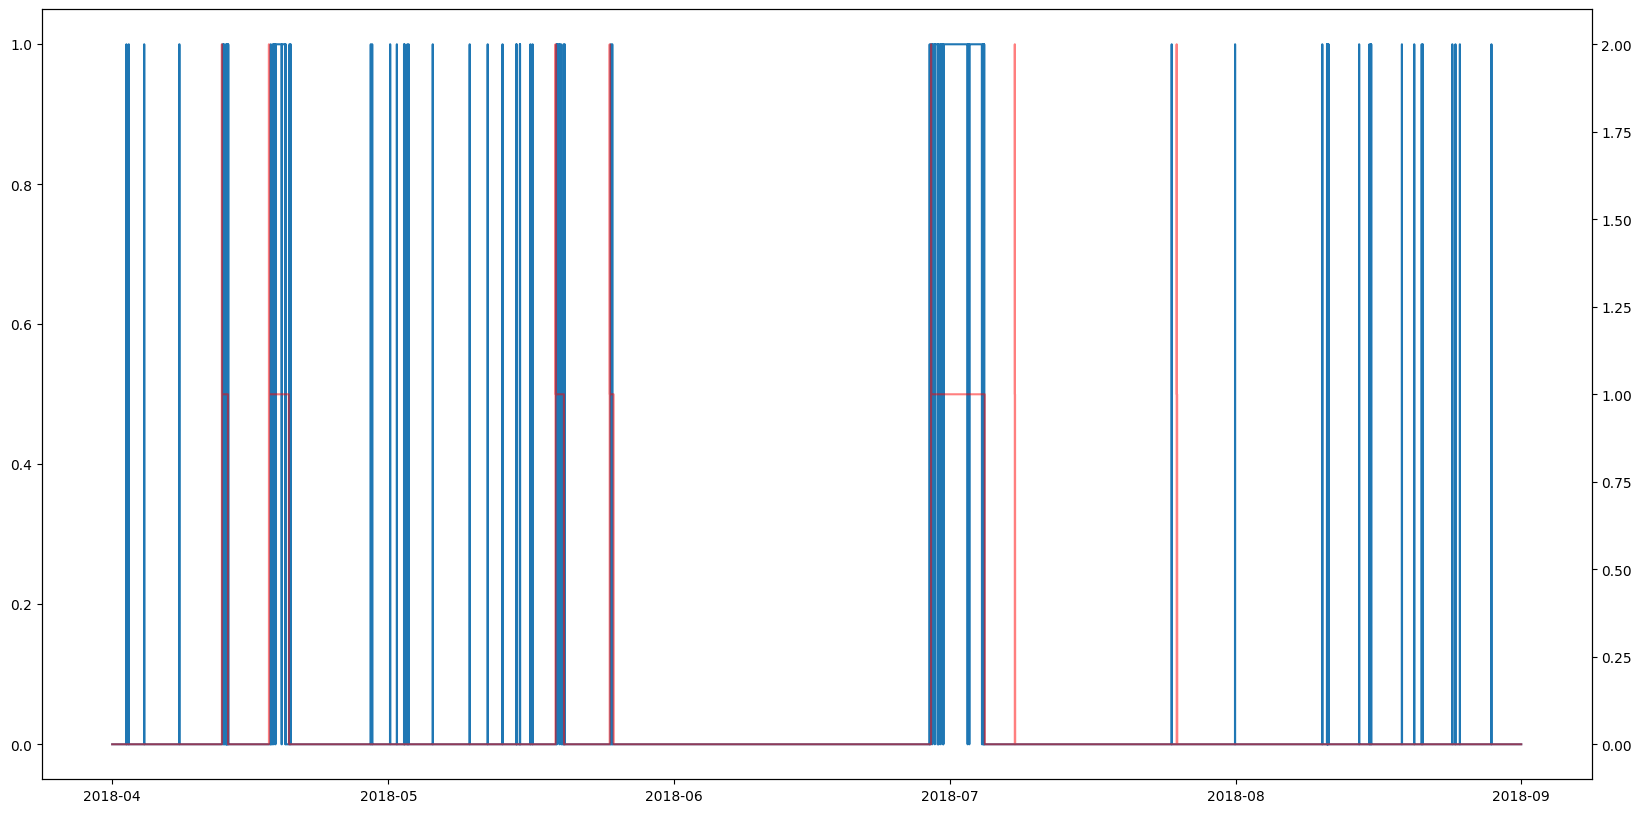

In [10]:
vis('sensor_39', 15, 0.2)

/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used

<Figure size 640x480 with 0 Axes>

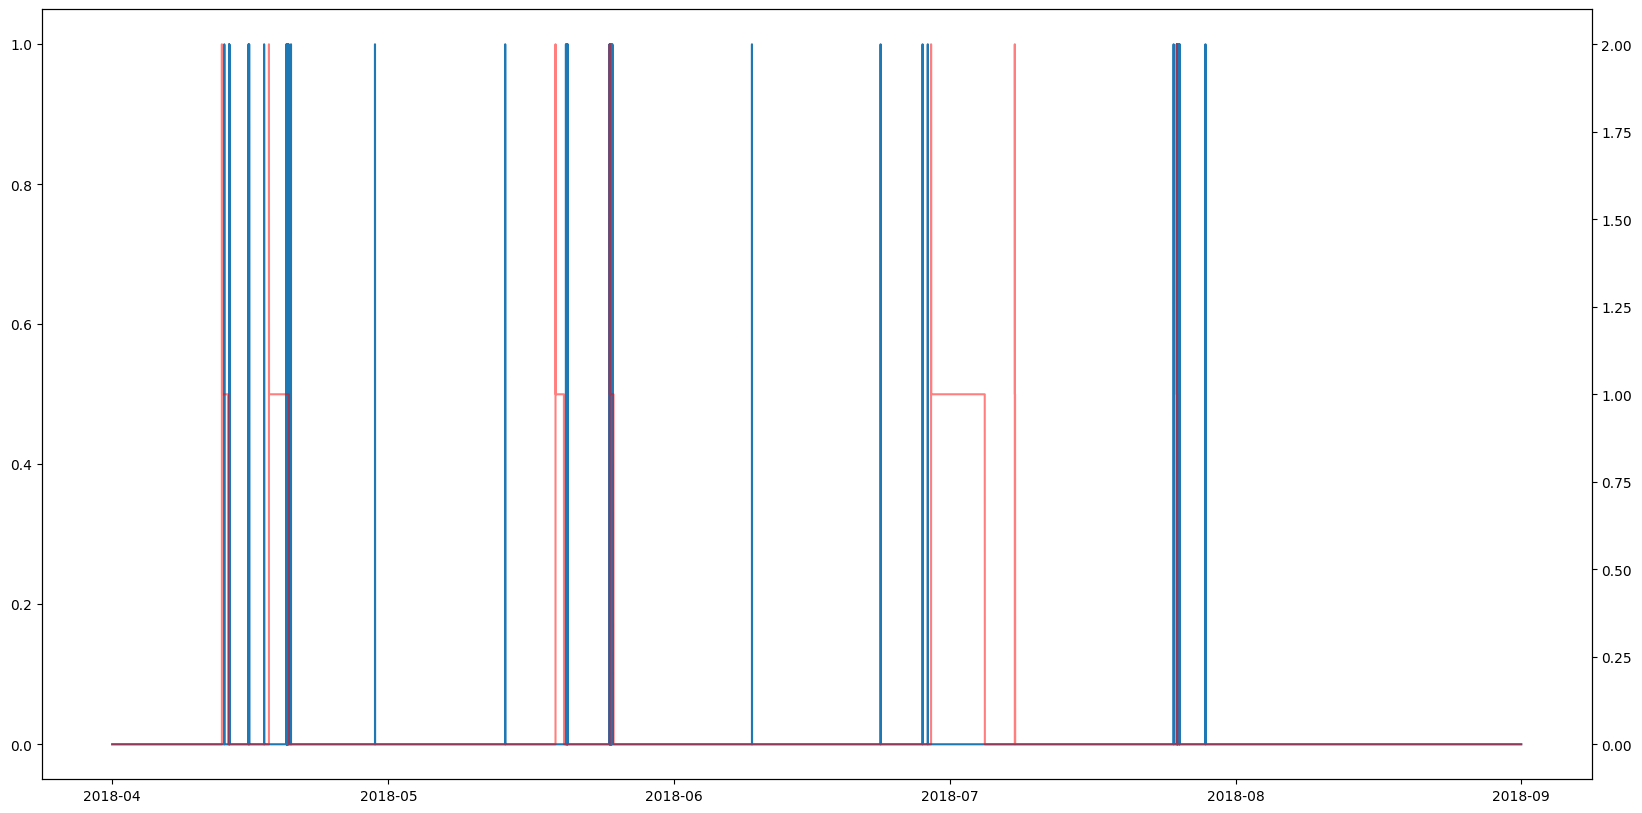

<Figure size 640x480 with 0 Axes>

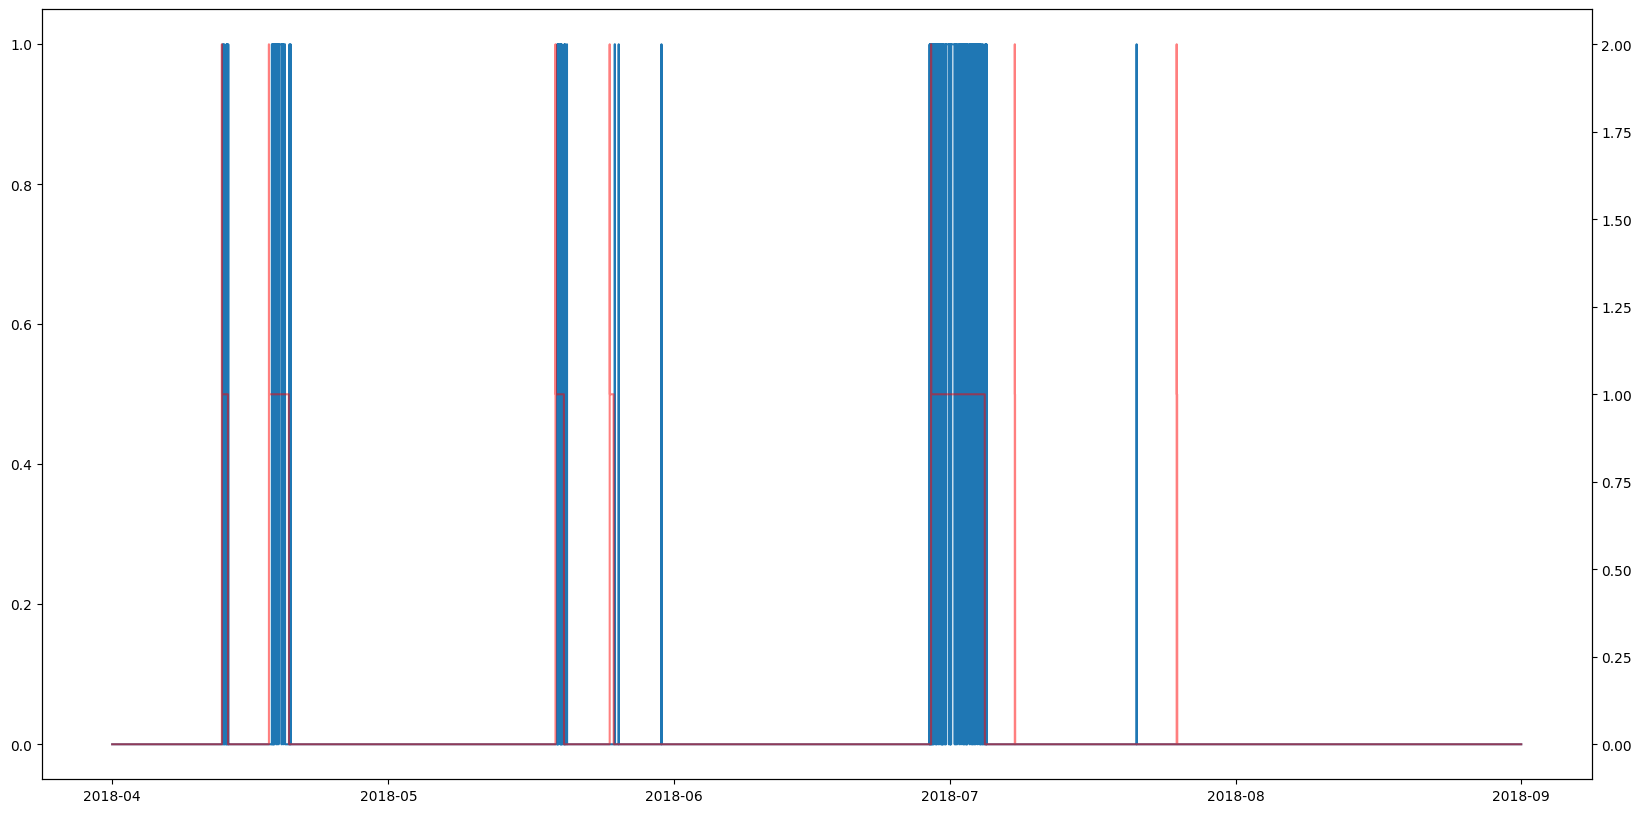

In [11]:
vis('sensor_41', 12, 0.27)

/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used

<Figure size 640x480 with 0 Axes>

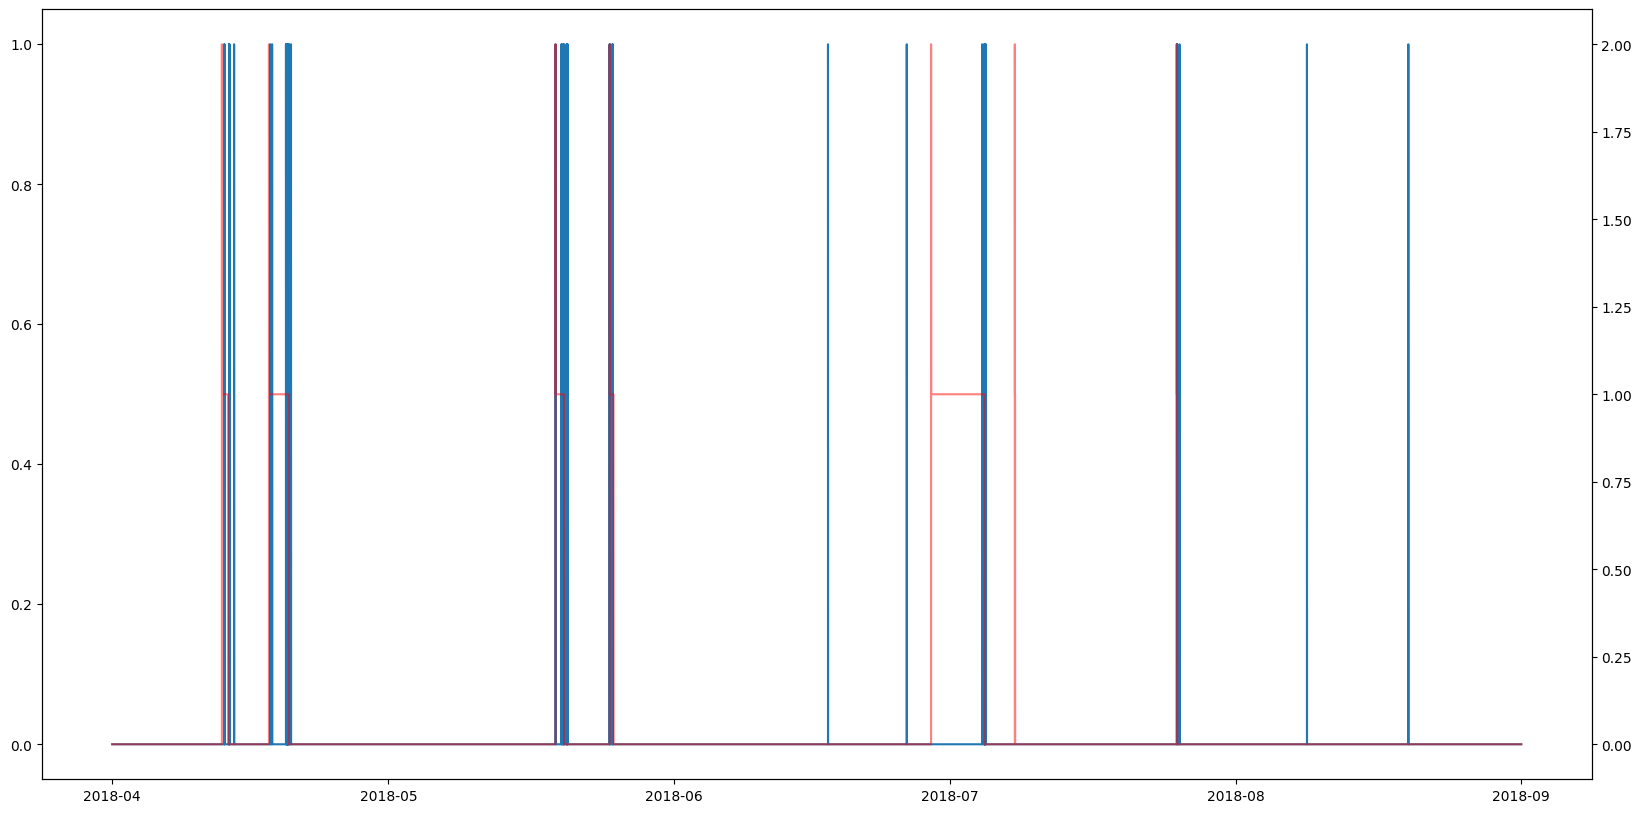

<Figure size 640x480 with 0 Axes>

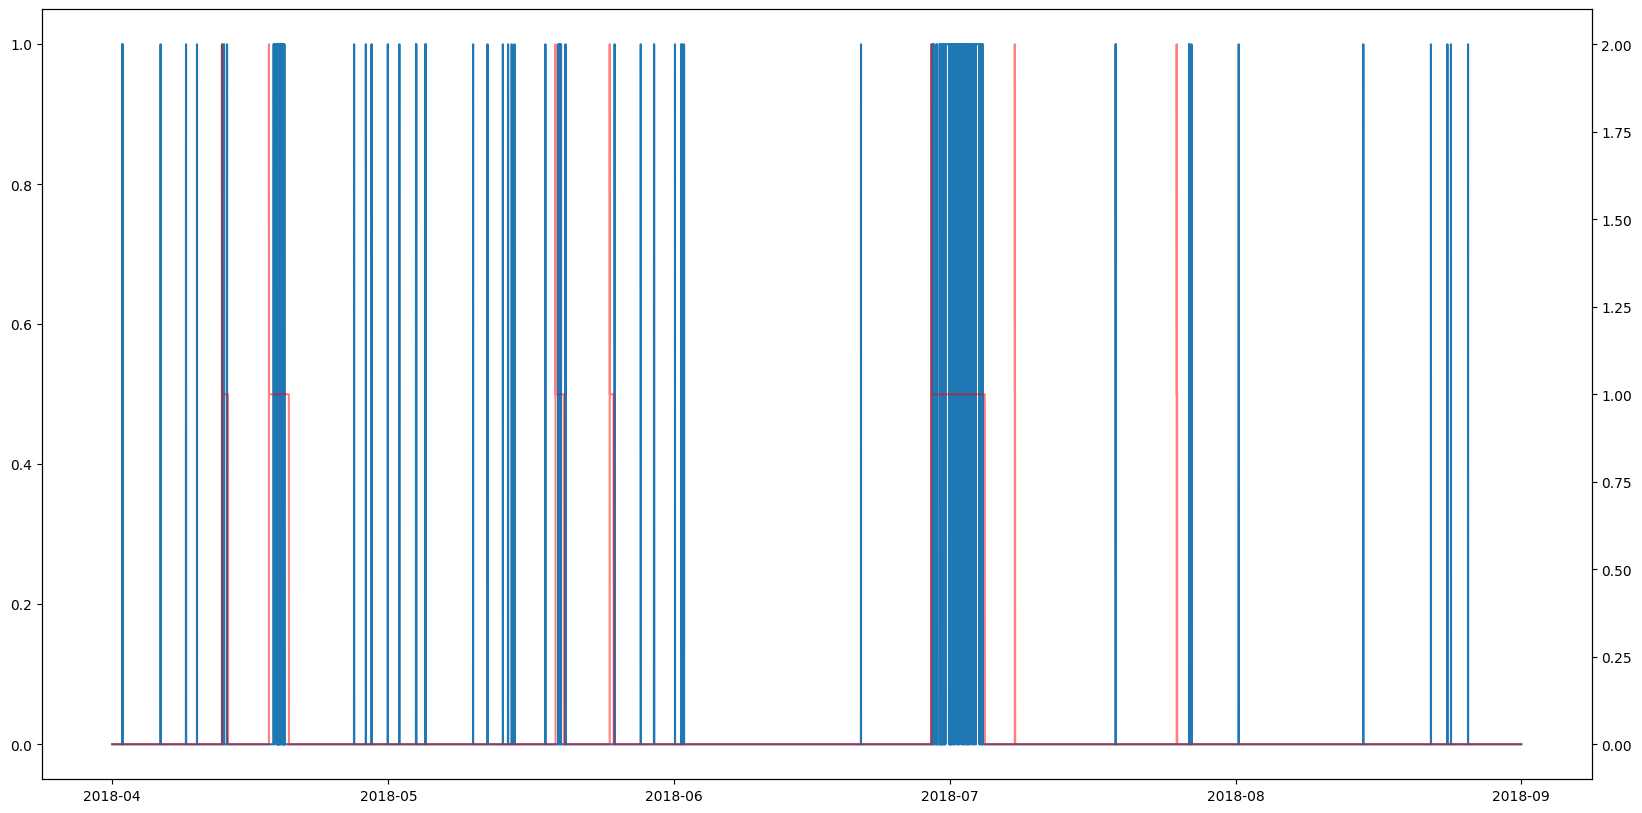

In [12]:
vis('sensor_42', 15, 0.25)

In [13]:
a_ratio_ls = (20,15,12,15)
b_ratio_ls = (0.35,0.2,0.27,0.25)

all_signal_a = []
all_signal_b = []

for col, a, b in zip(sensors, a_ratio_ls, b_ratio_ls):
    d = df[col].interpolate(method = 'linear')
    d_normal = d[df['machine_status']=='NORMAL']

    model = ARIMA(d_normal, order = (1,0,0))
    applied_to_full = model.fit().apply(d)
    residuals = applied_to_full.resid

    resid_normal_std = residuals[df['machine_status']=='NORMAL'].std()

    a_thres = a * resid_normal_std
    b_thres = b * resid_normal_std

    rolling_std = residuals.rolling(window=50).std()

    signal_a = residuals.abs() > a_thres
    signal_b = rolling_std < b_thres

    all_signal_a.append(signal_a)
    all_signal_b.append(signal_b)


/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used

In [14]:
from sklearn.metrics import classification_report

for a, b in zip(all_signal_a, all_signal_b):
    anomaly_bool = a|b
    y_true = (df['machine_status'] != 'NORMAL').astype(int)
    y_pred = anomaly_bool.astype(int)
    report = classification_report(y_true, y_pred, output_dict = True)
    result = pd.DataFrame(report).T.iloc[:2]
    print(result)

   precision    recall  f1-score   support
0   0.990479  0.994180  0.992326  205836.0
1   0.912650  0.864195  0.887762   14484.0
   precision    recall  f1-score   support
0   0.982127  0.996298  0.989162  205836.0
1   0.933820  0.742336  0.827141   14484.0
   precision    recall  f1-score   support
0   0.970910  0.998368  0.984448  205836.0
1   0.961214  0.574910  0.719488   14484.0
   precision    recall  f1-score   support
0   0.957973  0.997532  0.977352  205836.0
1   0.915107  0.378072  0.535079   14484.0


4つのanomaly_boolをORで統合

In [15]:
all_anomaly_bool = pd.Series(dtype = bool)

for a, b in zip(all_signal_a, all_signal_b):
    all_anomaly_bool = all_anomaly_bool|a|b

y_true = (df['machine_status'] != 'NORMAL').astype(int)
y_pred = all_anomaly_bool.astype(int)
report = classification_report(y_true, y_pred, output_dict = True)
result = pd.DataFrame(report).T.iloc[:2]
print(result)

   precision    recall  f1-score   support
0   0.995677  0.988068  0.991858  205836.0
1   0.847045  0.939036  0.890672   14484.0


ORで統合しているから、presicionは下がってしまうが、recallは上がった。
<br>ポンプの故障検知という文脈では、「見逃しの方が誤報より危険」のため、recall（実際に正解のもののうち、予測できたものの割合）の値を上げることが重要だと考えられる。

## Isolation Forestを適用

contamination（異常と定義する閾値を、X_normalデータのうちの何%点にするかという値）は、実験して評価結果を見て決めていく。

In [16]:
X_normal = df[df['machine_status'] == 'NORMAL'][sensors].interpolate(method = 'linear')
X_all = df[sensors].interpolate(method = 'linear')

In [27]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(contamination = 0.015, random_state=42)
clf.fit(X_normal)
pred = clf.predict(X_all) # -1: 異常, 1: 正常

In [28]:
y_pred_if = (pred == -1).astype(int)
report_if = classification_report(y_true, y_pred_if, output_dict = True)
result_if = pd.DataFrame(report_if).T
result_if

,precision,recall,f1-score,support
0,0.998513,0.985003,0.991712,205836.000000
1,0.821240,0.979149,0.893270,14484.000000
accuracy,0.984618,0.984618,0.984618,0.984618
macro avg,0.909877,0.982076,0.942491,220320.000000
weighted avg,0.986859,0.984618,0.985240,220320.000000


## ARIMA + IF のアンサンブル（OR）

In [29]:
y_pred_ensemble = y_pred|y_pred_if
report_ensemble = classification_report(y_true, y_pred_ensemble, output_dict = True)
result_ensemble = pd.DataFrame(report_ensemble).T
result_ensemble

,precision,recall,f1-score,support
0,0.999792,0.979795,0.989692,205836.000000
1,0.776410,0.997100,0.873024,14484.000000
accuracy,0.980932,0.980932,0.980932,0.980932
macro avg,0.888101,0.988447,0.931358,220320.000000
weighted avg,0.985106,0.980932,0.982022,220320.000000


ORでアンサンブルする場合、構造的にrecallは上昇し、presicionは下がるというのは確定している。